# Image Captioning

**Credits:** This code is based on https://keras.io/examples/vision/image_captioning/. It changes that example in these ways:

- The frozen CNN's image features are computed once and cached on disk, instead of being recomputed for every batch of every epoch.
- It uses the official Flickr8k train/dev/test split, and the vocabulary is built from the training captions only.
- KerasTuner tunes the hyperparameters, and each trial is scored by BLEU-4 on the dev set.
- Captions are decoded with beam search. The tuned model is compared with the example's settings using BLEU on the held-out test set.

## Setup

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import functools
import json
import math
import re
import warnings
from collections import Counter
from pathlib import Path

# The installed protobuf runtime is newer than the one TensorFlow was generated with,
# which prints a version warning for every TensorFlow proto at import time
warnings.filterwarnings("ignore", message="Protobuf gencode version")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sacrebleu.metrics import BLEU

import tensorflow as tf
import keras
from keras import layers
from keras.layers import TextVectorization
import keras_tuner as kt

# Fixes the data order, weight initialization, feature flips and the tuner's choices
SEED = 420
keras.utils.set_random_seed(SEED)

# On an Apple-silicon Mac without tensorflow-metal this lists only the CPU
print("TensorFlow devices:", [device.name for device in tf.config.list_physical_devices()])

TensorFlow devices: ['/physical_device:CPU:0']


## The dataset

We will be using the Flickr8K dataset. This dataset comprises over 8,000 images, each paired with five different captions. It also comes with an official split of 6,000 training, 1,000 dev (validation) and 1,000 test images.

The two archives (`Flickr8k_Dataset.zip` and `Flickr8k_text.zip`) are at https://github.com/jbrownlee/Datasets/releases/tag/Flickr8k. The notebook expects them unpacked under `data/flickr8k/`, or under the folder named by the `FLICKR8K_DATA_ROOT` environment variable:

```
data/flickr8k/
    Flicker8k_Dataset/     the images (the misspelling comes from the archive)
    Flickr8k_text/         Flickr8k.token.txt, Flickr_8k.trainImages.txt, ...
```

In [2]:
data_root = Path(os.environ.get("FLICKR8K_DATA_ROOT", "data"))
data_dir = data_root / "flickr8k"

# Path to the images
IMAGES_PATH = data_dir / "Flicker8k_Dataset"
# Path to the captions and the split files
TEXT_PATH = data_dir / "Flickr8k_text"
assert (TEXT_PATH / "Flickr8k.token.txt").exists(), f"Flickr8k not found under {data_dir}"

# Desired image dimensions
IMAGE_SIZE = (299, 299)

# The frozen CNN's features are computed once and cached here (about 3.6 GB)
FEATURES_DIR = data_root / f"flickr8k_features_efficientnetv2l_{IMAGE_SIZE[0]}"

# Words that appear fewer times than this in the training captions become [UNK]
MIN_WORD_COUNT = 5

# Fixed length allowed for any sequence, including the <start> and <end> tokens
SEQ_LENGTH = 25

# Dimension for the image embeddings and token embeddings
EMBED_DIM = 512

# Per-layer units in the feed-forward network
FF_DIM = 512

# Other training parameters
BATCH_SIZE = 64
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE

# Hyperparameter search budget and where the tuner keeps its trials
MAX_TRIALS = 10
TUNER_DIR = "tuner_results"

# Number of candidate captions kept while decoding
BEAM_WIDTH = 3

# Where the final model's weights, vocabulary and hyperparameters are saved
MODEL_DIR = Path("models")

## Preparing the dataset

The training and dev images must fit the model. If any of an image's captions is shorter than 5 words, or too long to fit in `SEQ_LENGTH` with the `<start>` and `<end>` tokens, we drop that image, so every image kept has exactly five captions. The test set keeps every image and caption, so BLEU is measured on the whole official test split.

In [3]:
def load_captions_data(filename):
    """Loads captions (text) data and maps them to corresponding images.

    Args:
        filename: Path to the text file containing caption data.

    Returns:
        caption_mapping: Dictionary mapping each image file name to its five captions
    """
    caption_mapping = {}
    with open(filename) as caption_file:
        for line in caption_file:
            # Image name and captions are separated using a tab
            img_name, caption = line.rstrip("\n").split("\t")

            # Each image is repeated five times for the five different captions.
            # Each image name has a suffix `#(caption_number)`
            img_name = img_name.split("#")[0].strip()

            # One stray entry in the file ends in `.jpg.1`
            if img_name.endswith("jpg"):
                caption_mapping.setdefault(img_name, []).append(caption.strip())

    return caption_mapping


def keep_trainable(caption_mapping):
    """Keeps only the images whose five captions all fit the model."""

    def fits(caption):
        # Leave room for the <start> and <end> tokens
        return 5 <= len(caption.split()) <= SEQ_LENGTH - 2

    return {
        img_name: captions
        for img_name, captions in caption_mapping.items()
        if all(fits(caption) for caption in captions)
    }


def read_split(name):
    """Lists the image file names in one of the official splits (train, dev or test)."""
    return (TEXT_PATH / f"Flickr_8k.{name}Images.txt").read_text().split()


# Load the dataset
captions_mapping = load_captions_data(TEXT_PATH / "Flickr8k.token.txt")
assert all(len(captions) == 5 for captions in captions_mapping.values())

split_images = {name: read_split(name) for name in ("train", "dev", "test")}
missing = [name for names in split_images.values() for name in names if not (IMAGES_PATH / name).exists()]
assert not missing, f"{len(missing)} images are missing, e.g. {missing[:3]}"

train_data = keep_trainable({name: captions_mapping[name] for name in split_images["train"]})
valid_data = keep_trainable({name: captions_mapping[name] for name in split_images["dev"]})
test_data = {name: captions_mapping[name] for name in split_images["test"]}

print("Number of training samples:   ", len(train_data), "of", len(split_images["train"]))
print("Number of validation samples: ", len(valid_data), "of", len(split_images["dev"]))
print("Number of test samples:       ", len(test_data))

Number of training samples:    5547 of 6000
Number of validation samples:  925 of 1000
Number of test samples:        1000


## Vectorizing the text data

We'll use the `TextVectorization` layer to vectorize the text data. It turns the original strings into integer sequences, where each integer is the index of a word in a vocabulary. We will use a custom string standardization scheme (strip punctuation characters except `<` and `>`) and the default splitting scheme (split on whitespace).

The vocabulary comes from the training captions only, so dev and test text never influences the model. It keeps words that appear at least `MIN_WORD_COUNT` times, and the rarer words map to `[UNK]`. Most Flickr8k words appear only a handful of times, so this makes the model's output layer much smaller.

In [4]:
strip_chars = "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"
strip_chars = strip_chars.replace("<", "")
strip_chars = strip_chars.replace(">", "")
strip_pattern = "[%s]" % re.escape(strip_chars)


def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, strip_pattern, "")


def standardize(text):
    """Python version of `custom_standardization`, for word counts and BLEU references."""
    return " ".join(re.sub(strip_pattern, "", text.lower()).split())


def add_special_tokens(caption):
    return "<start> " + caption + " <end>"


word_counts = Counter(
    word
    for captions in train_data.values()
    for caption in captions
    for word in standardize(caption).split()
)
vocabulary = ["<start>", "<end>"] + [
    word for word, count in word_counts.most_common() if count >= MIN_WORD_COUNT
]

vectorization = TextVectorization(
    vocabulary=vocabulary,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
    standardize=custom_standardization,
)
VOCAB_SIZE = vectorization.vocabulary_size()
print(f"Vocabulary size: {VOCAB_SIZE} ({len(word_counts)} distinct words in the training captions)")

Vocabulary size: 2426 (7290 distinct words in the training captions)


## Caching the image features

The CNN (EfficientNetV2L, pre-trained on ImageNet) is frozen, so an image's features never change during training. We run it once over every image and cache the resulting 10×10 grid of 1,280-dimensional features. On a CPU this takes about half a second per image, so the first run spends a couple of hours here, and later runs load the cache from disk.

Because the features are computed ahead of time, the images can't be randomly augmented while training. As a replacement, we also cache the features of horizontally flipped training images, and each epoch uses the flipped copy for a random half of the images. Vertical flips and large rotations would produce scenes that no longer match their captions, so we don't use them.

In [5]:
def decode_and_resize(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    # EfficientNetV2 rescales its inputs itself, so the pixels stay in [0, 255]
    img = tf.image.resize(img, IMAGE_SIZE)
    return img


@functools.cache
def get_cnn_model():
    base_model = keras.applications.EfficientNetV2L(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )

    # We freeze our feature extractor
    base_model.trainable = False
    base_model_out = base_model.output
    base_model_out = layers.Reshape((-1, base_model_out.shape[-1]))(base_model_out)
    cnn_model = keras.models.Model(base_model.input, base_model_out)

    return cnn_model


def cached_features(image_names, cache_path, flip=False, batch_size=32):
    """Returns the CNN features of the images, computing and caching them if needed.

    The result is a read-only memory map of shape (images, patches, channels) in float16,
    with one row per image in the order of `image_names`.
    """
    names_path = cache_path.with_suffix(".json")
    if (
        cache_path.exists()
        and names_path.exists()
        and json.loads(names_path.read_text()) == list(image_names)
    ):
        return np.load(cache_path, mmap_mode="r")

    print(f"Computing {cache_path.name} ...")
    cnn_model = get_cnn_model()
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    # No prefetching: the CNN takes far longer per batch than reading the images does
    dataset = (
        tf.data.Dataset.from_tensor_slices([str(IMAGES_PATH / name) for name in image_names])
        .map(decode_and_resize, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
    )

    # Write to a temporary file first, so an interrupted run never leaves a partial cache
    tmp_path = cache_path.with_suffix(".tmp.npy")
    features = np.lib.format.open_memmap(
        tmp_path,
        mode="w+",
        dtype=np.float16,
        shape=(len(image_names), *cnn_model.output.shape[1:]),
    )
    progbar = keras.utils.Progbar(len(image_names), unit_name="image")
    done = 0
    for images in dataset:
        if flip:
            images = tf.image.flip_left_right(images)
        batch_features = cnn_model.predict_on_batch(images)
        features[done : done + len(batch_features)] = batch_features
        done += len(batch_features)
        progbar.update(done)
    features.flush()
    del features

    os.replace(tmp_path, cache_path)
    names_path.write_text(json.dumps(list(image_names)))
    return np.load(cache_path, mmap_mode="r")


features = {
    "dev": cached_features(split_images["dev"], FEATURES_DIR / "dev.npy"),
    "test": cached_features(split_images["test"], FEATURES_DIR / "test.npy"),
    "train": cached_features(split_images["train"], FEATURES_DIR / "train.npy"),
    "train_flipped": cached_features(
        split_images["train"], FEATURES_DIR / "train_flipped.npy", flip=True
    ),
}
# The CNN is no longer needed, so free its memory
get_cnn_model.cache_clear()

FEATURE_SHAPE = features["train"].shape[1:]
print("Features per image:", FEATURE_SHAPE)

Features per image: (100, 1280)


## Building the data pipeline for training

Each batch pairs the cached features of `BATCH_SIZE` images with the tokenized five captions of each image. The dev and test features are small enough to load into memory, together with the reference captions that BLEU compares against.

In [6]:
def split_rows(split, names):
    """Finds the row of each image in that split's feature cache."""
    row_of = {name: i for i, name in enumerate(split_images[split])}
    return np.array([row_of[name] for name in names])


def vectorize_captions(data, names):
    captions = [add_special_tokens(caption) for name in names for caption in data[name]]
    return vectorization(captions).numpy().reshape(len(names), 5, SEQ_LENGTH)


class CaptionDataset(keras.utils.PyDataset):
    """Batches of (image features, the image's five tokenized captions)."""

    def __init__(self, data, split, shuffle=False, flipped_features=None, **kwargs):
        super().__init__(**kwargs)
        names = sorted(data)
        self.features = features[split]
        self.rows = split_rows(split, names)
        self.captions = vectorize_captions(data, names)
        self.flipped_features = flipped_features
        self.shuffle = shuffle
        self.rng = np.random.default_rng(SEED)
        self.order = np.arange(len(names))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.order) / BATCH_SIZE)

    def __getitem__(self, idx):
        batch = self.order[idx * BATCH_SIZE : (idx + 1) * BATCH_SIZE]
        rows = self.rows[batch]
        batch_features = self.features[rows].astype("float32")
        if self.flipped_features is not None:
            # Each image uses the features of its flipped copy half of the time
            flip = self.rng.random(len(rows)) < 0.5
            batch_features[flip] = self.flipped_features[rows[flip]]
        return batch_features, self.captions[batch]

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)


train_dataset = CaptionDataset(
    train_data, "train", shuffle=True, flipped_features=features["train_flipped"]
)
valid_dataset = CaptionDataset(valid_data, "dev")

# Features and standardized reference captions for BLEU on the dev and test images
valid_names = sorted(valid_data)
valid_features = np.asarray(features["dev"][split_rows("dev", valid_names)])
valid_references = [[standardize(c) for c in valid_data[name]] for name in valid_names]

test_names = sorted(test_data)
test_features = np.asarray(features["test"][split_rows("test", test_names)])
test_references = [[standardize(c) for c in test_data[name]] for name in test_names]

batch_features, batch_captions = train_dataset[0]
print("One batch:", batch_features.shape, batch_captions.shape)

One batch: (64, 100, 1280) (64, 5, 25)


## Building the model

Our image captioning architecture consists of three models:

1. A CNN: used to extract the image features (computed ahead of time above)
2. A TransformerEncoder: The extracted image features are then passed to a Transformer
                    based encoder that generates a new representation of the inputs
3. A TransformerDecoder: This model takes the encoder output and the text data
                    (sequences) as inputs and tries to learn to generate the caption.

The decoder outputs logits rather than probabilities. The loss applies the softmax itself (`from_logits=True`), which is more numerically stable. Each attention head works on an equal slice of the embedding, so adding heads doesn't add computation.

In [7]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.activation = activation
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.0
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.dense_1 = layers.Dense(embed_dim, activation=activation)

    def call(self, inputs, training, mask=None):
        inputs = self.layernorm_1(inputs)
        inputs = self.dense_1(inputs)

        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=None,
            training=training,
        )
        out_1 = self.layernorm_2(inputs + attention_output_1)
        return out_1


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.embed_scale = tf.math.sqrt(tf.cast(embed_dim, tf.float32))

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_tokens = embedded_tokens * self.embed_scale
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return tf.math.not_equal(inputs, 0)


class TransformerDecoderBlock(layers.Layer):
    def __init__(
        self,
        embed_dim,
        ff_dim,
        num_heads,
        sequence_length,
        vocab_size,
        activation="relu",
        dropout1=0.1,
        dropout2=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.num_heads = num_heads
        self.activation = activation
        self.dropout1 = dropout1
        self.dropout2 = dropout2

        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1
        )
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1
        )
        self.ffn_layer_1 = layers.Dense(ff_dim, activation=activation)
        self.ffn_layer_2 = layers.Dense(embed_dim)

        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()

        self.embedding = PositionalEmbedding(
            embed_dim=embed_dim,
            sequence_length=sequence_length,
            vocab_size=vocab_size,
        )
        # Logits for every vocabulary entry; the loss applies the softmax
        self.out = layers.Dense(vocab_size)

        self.dropout_1 = layers.Dropout(dropout1)
        self.dropout_2 = layers.Dropout(dropout2)
        self.supports_masking = True

    def call(self, inputs, encoder_outputs, training, mask=None):
        inputs = self.embedding(inputs)
        causal_mask = self.get_causal_attention_mask(inputs)

        if mask is not None:
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            combined_mask = tf.minimum(combined_mask, causal_mask)

        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=combined_mask,
            training=training,
        )
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
            training=training,
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        ffn_out = self.ffn_layer_1(out_2)
        ffn_out = self.dropout_1(ffn_out, training=training)
        ffn_out = self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2, training=training)
        ffn_out = self.dropout_2(ffn_out, training=training)
        preds = self.out(ffn_out)
        return preds

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [
                tf.expand_dims(batch_size, -1),
                tf.constant([1, 1], dtype=tf.int32),
            ],
            axis=0,
        )
        return tf.tile(mask, mult)


class ImageCaptioningModel(keras.Model):
    def __init__(self, encoder, decoder, num_captions_per_image=5):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker = keras.metrics.Mean(name="acc")
        self.num_captions_per_image = num_captions_per_image

    def build(self, input_shape):
        # The model has no `call`, so Keras can't create its weights by itself. Run the
        # encoder and decoder once instead; saving and loading weights need them to exist.
        feature_shape, caption_shape = input_shape
        img_embed = tf.zeros((1, *feature_shape[1:]))
        batch_seq = tf.ones((1, caption_shape[-1] - 1), dtype="int64")
        encoder_out = self.encoder(img_embed, training=False)
        self.decoder(batch_seq, encoder_out, training=False, mask=tf.not_equal(batch_seq, 0))

    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)

    def _compute_caption_loss_and_acc(self, img_embed, batch_seq, training=True):
        encoder_out = self.encoder(img_embed, training=training)
        batch_seq_inp = batch_seq[:, :-1]
        batch_seq_true = batch_seq[:, 1:]
        mask = tf.math.not_equal(batch_seq_true, 0)
        batch_seq_pred = self.decoder(
            batch_seq_inp, encoder_out, training=training, mask=mask
        )
        # Mean cross-entropy over the real (non-padding) tokens: a scalar
        loss = self.calculate_loss(batch_seq_true, batch_seq_pred, mask)
        acc = self.calculate_accuracy(batch_seq_true, batch_seq_pred, mask)
        return loss, acc

    def train_step(self, batch_data):
        img_embed, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        # 1. Pass each of the five captions one by one to the decoder
        # along with the image features and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            with tf.GradientTape() as tape:
                loss, acc = self._compute_caption_loss_and_acc(
                    img_embed, batch_seq[:, i, :], training=True
                )

                # 2. Update loss and accuracy
                batch_loss += loss
                batch_acc += acc

            # 3. Get the list of all the trainable weights
            train_vars = (
                self.encoder.trainable_variables + self.decoder.trainable_variables
            )

            # 4. Get the gradients
            grads = tape.gradient(loss, train_vars)

            # 5. Update the trainable weights
            self.optimizer.apply_gradients(zip(grads, train_vars))

        # 6. Update the trackers with the averages over the five captions
        self.loss_tracker.update_state(batch_loss / self.num_captions_per_image)
        self.acc_tracker.update_state(batch_acc / self.num_captions_per_image)

        # 7. Return the loss and accuracy values
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, batch_data):
        img_embed, batch_seq = batch_data
        batch_loss = 0
        batch_acc = 0

        # 1. Pass each of the five captions one by one to the decoder
        # along with the image features and compute the loss as well as accuracy
        # for each caption.
        for i in range(self.num_captions_per_image):
            loss, acc = self._compute_caption_loss_and_acc(
                img_embed, batch_seq[:, i, :], training=False
            )

            # 2. Update batch loss and batch accuracy
            batch_loss += loss
            batch_acc += acc

        # 3. Update the trackers with the averages over the five captions
        self.loss_tracker.update_state(batch_loss / self.num_captions_per_image)
        self.acc_tracker.update_state(batch_acc / self.num_captions_per_image)

        # 4. Return the loss and accuracy values
        return {m.name: m.result() for m in self.metrics}

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker, self.acc_tracker]

## Generating captions and measuring BLEU

`generate_captions` decodes many images at once with beam search. It keeps the `beam_width` most likely partial captions for each image, and `beam_width=1` is plain greedy decoding. While decoding, beams are ranked by their total log-probability. At the end, each image gets the beam with the best average log-probability per token, so a caption isn't penalized just for being longer.

BLEU-*n* measures how many of a caption's 1- to *n*-word sequences appear in any of the image's five reference captions, with a penalty for captions that are too short. It is computed over the whole set of images (corpus BLEU), on a scale of 0–100. Both the generated and the reference captions go through the same standardization, lowercase with punctuation removed.

In [8]:
vocab = vectorization.get_vocabulary()
start_id = vocab.index("<start>")
end_id = vocab.index("<end>")
max_decoded_sentence_length = SEQ_LENGTH - 1


def generate_captions(model, image_features, beam_width=1, batch_size=250):
    """Captions the images whose cached features are given, with beam search.

    Padding, [UNK] and <start> are never generated.
    """
    captions = []
    for start in range(0, len(image_features), batch_size):
        img_embed = np.asarray(image_features[start : start + batch_size], dtype="float32")
        n, k = len(img_embed), beam_width

        # Encode each image once, then give each of its k beams a copy
        encoded_img = tf.repeat(model.encoder(img_embed, training=False), k, axis=0)

        tokens = np.zeros((n, k, max_decoded_sentence_length), dtype="int64")
        tokens[:, :, 0] = start_id
        # All beams start out identical, so only the first one is expanded at first
        scores = np.zeros((n, k))
        scores[:, 1:] = -np.inf
        lengths = np.zeros((n, k))
        finished = np.zeros((n, k), dtype=bool)

        for i in range(max_decoded_sentence_length - 1):
            tokenized_caption = tf.constant(tokens.reshape(n * k, -1))
            logits = model.decoder(
                tokenized_caption,
                encoded_img,
                training=False,
                mask=tf.not_equal(tokenized_caption, 0),
            )
            log_probs = tf.nn.log_softmax(logits[:, i, :]).numpy().reshape(n, k, -1)
            log_probs[:, :, [0, 1, start_id]] = -np.inf
            # A finished beam can only be extended with padding, at no cost
            log_probs[finished] = -np.inf
            log_probs[finished, 0] = 0.0

            # Keep the k best extensions of all k beams of each image
            candidates = (scores[:, :, np.newaxis] + log_probs).reshape(n, -1)
            best = np.argsort(-candidates, axis=1)[:, :k]
            beam_ids, token_ids = np.divmod(best, log_probs.shape[-1])
            image_ids = np.arange(n)[:, np.newaxis]

            tokens = tokens[image_ids, beam_ids]
            tokens[:, :, i + 1] = token_ids
            scores = candidates[image_ids, best]
            was_finished = finished[image_ids, beam_ids]
            lengths = lengths[image_ids, beam_ids] + ~was_finished
            finished = was_finished | (token_ids == end_id)
            if finished.all():
                break

        chosen = tokens[np.arange(n), np.argmax(scores / lengths, axis=1)]
        for sequence in chosen:
            words = [vocab[t] for t in sequence[1:] if t not in (0, end_id)]
            captions.append(" ".join(words))
    return captions


def bleu_scores(hypotheses, references):
    """Corpus BLEU-1 to BLEU-4 of the generated captions against all five references."""
    # sacrebleu takes one list per reference "stream": the i-th reference of every image
    reference_streams = [list(stream) for stream in zip(*references)]
    return {
        f"bleu{n}": BLEU(max_ngram_order=n, tokenize="none")
        .corpus_score(hypotheses, reference_streams)
        .score
        for n in range(1, 5)
    }

## Hyperparameter search

Every trial uses AdamW. Its learning rate warms up linearly over the first 2 of the 30 epochs, then follows a cosine decay. Training stops early once the validation loss stops improving.

Each trial is scored by the BLEU-4 of its greedy captions on the dev images. The validation loss can't serve this purpose, because it only tells how well the model predicts the next word given the correct previous words, while BLEU scores the captions it actually writes. The tuner keeps its trials in `tuner_results/image_captioning` with `overwrite=False`, so re-running this cell resumes an interrupted search instead of discarding it.

In [9]:
# EarlyStopping criteria
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# The optimizer takes one step per caption, so five per batch
steps_per_epoch = len(train_dataset) * 5
total_steps = steps_per_epoch * EPOCHS
warmup_steps = total_steps // 15


def make_optimizer(learning_rate):
    schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.0,
        decay_steps=total_steps - warmup_steps,
        warmup_target=learning_rate,
        warmup_steps=warmup_steps,
    )
    return keras.optimizers.AdamW(learning_rate=schedule)


class CaptioningHyperModel(kt.HyperModel):
    def build(self, hp):
        learning_rate = hp.Float("lr", min_value=1e-5, max_value=1e-3, sampling="log")

        # Define and tune hyperparameters for the TransformerEncoderBlock
        encoder = TransformerEncoderBlock(
            embed_dim=EMBED_DIM,
            num_heads=hp.Choice("encoder_num_heads", values=[1, 2]),
            activation=hp.Choice("encoder_activation", ["relu", "silu", "gelu", "celu"]),
        )

        # Define and tune hyperparameters for the TransformerDecoderBlock
        decoder = TransformerDecoderBlock(
            embed_dim=EMBED_DIM,
            ff_dim=FF_DIM,
            num_heads=hp.Choice("decoder_num_heads", values=[1, 2, 4]),
            sequence_length=SEQ_LENGTH,
            vocab_size=VOCAB_SIZE,
            activation=hp.Choice("decoder_activation", ["relu", "silu", "gelu", "celu"]),
            dropout1=hp.Float("decoder_dropout1", min_value=0.1, max_value=0.6, step=0.1),
            dropout2=hp.Float("decoder_dropout2", min_value=0.1, max_value=0.6, step=0.1),
        )

        caption_model = ImageCaptioningModel(encoder=encoder, decoder=decoder)
        caption_model.compile(
            optimizer=make_optimizer(learning_rate),
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction=None),
        )
        caption_model.build([(None, *FEATURE_SHAPE), (None, 5, SEQ_LENGTH)])
        return caption_model

    def fit(self, hp, model, *args, **kwargs):
        history = model.fit(*args, **kwargs)
        # Score the trial by the BLEU-4 of its greedy captions for the dev images
        captions = generate_captions(model, valid_features)
        return {
            "val_bleu4": bleu_scores(captions, valid_references)["bleu4"],
            "val_loss": min(history.history["val_loss"]),
        }


hypermodel = CaptioningHyperModel()

model_tuner = kt.RandomSearch(
    hypermodel=hypermodel,
    objective=kt.Objective("val_bleu4", direction="max"),
    max_trials=MAX_TRIALS,
    executions_per_trial=1,
    seed=SEED,
    overwrite=False,
    directory=TUNER_DIR,
    project_name="image_captioning",
)
model_tuner.search_space_summary()
model_tuner.search(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=2,
)
model_tuner.results_summary(num_trials=5)

Reloading Tuner from tuner_results/image_captioning/tuner0.json
Search space summary
Default search space size: 7
lr (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
encoder_num_heads (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2], 'ordered': True}
encoder_activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'gelu', 'celu'], 'ordered': False}
decoder_num_heads (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2, 4], 'ordered': True}
decoder_activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'gelu', 'celu'], 'ordered': False}
decoder_dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
decoder_dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
Results summary
Results in tuner_results/image_caption

## Final training and evaluation on the test set

We train two models from scratch on the training images: one with the best hyperparameters from the search, and a baseline with the keras.io example's settings (1 encoder head, 2 decoder heads, ReLU, decoder dropout 0.3 and 0.5, learning rate 1e-4). Both use the same optimizer and learning-rate schedule. The test images were not used for training, early stopping or choosing hyperparameters, so their BLEU scores estimate how the models do on new images.

In [13]:
def train_and_evaluate(hp):
    keras.utils.set_random_seed(SEED)
    model = hypermodel.build(hp)
    history = model.fit(
        train_dataset,
        validation_data=valid_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
        verbose=2,
    )
    results = {"val_loss": min(history.history["val_loss"])}
    for decoding, beam_width in [("greedy", 1), (f"beam {BEAM_WIDTH}", BEAM_WIDTH)]:
        captions = generate_captions(model, test_features, beam_width=beam_width)
        results[decoding] = bleu_scores(captions, test_references)
    return model, results


baseline_hp = kt.HyperParameters()
for name, value in {
    "lr": 1e-4,
    "encoder_num_heads": 1,
    "encoder_activation": "relu",
    "decoder_num_heads": 2,
    "decoder_activation": "relu",
    "decoder_dropout1": 0.3,
    "decoder_dropout2": 0.5,
}.items():
    baseline_hp.Fixed(name, value)

best_hp = model_tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hp.values)

print("\nTraining the baseline")
baseline_model, baseline_results = train_and_evaluate(baseline_hp)
print("\nTraining with the tuned hyperparameters")
best_model, tuned_results = train_and_evaluate(best_hp)

rows = []
for model_name, results in [("keras.io settings", baseline_results), ("tuned", tuned_results)]:
    for decoding in ("greedy", f"beam {BEAM_WIDTH}"):
        rows.append(
            {"model": model_name, "decoding": decoding, "dev loss": results["val_loss"]}
            | {name.upper(): score for name, score in results[decoding].items()}
        )
results_table = pd.DataFrame(rows).set_index(["model", "decoding"])
results_table.round(2)

Best hyperparameters: {'lr': 3.6370716699464735e-05, 'encoder_num_heads': 1, 'encoder_activation': 'relu', 'decoder_num_heads': 1, 'decoder_activation': 'silu', 'decoder_dropout1': 0.2, 'decoder_dropout2': 0.2}

Training the baseline
Epoch 1/30
87/87 - 327s - 4s/step - acc: 0.1542 - loss: 6.0030 - val_acc: 0.2626 - val_loss: 4.4406
Epoch 2/30
87/87 - 265s - 3s/step - acc: 0.2884 - loss: 4.2081 - val_acc: 0.3395 - val_loss: 3.6202
Epoch 3/30
87/87 - 273s - 3s/step - acc: 0.3395 - loss: 3.5923 - val_acc: 0.3648 - val_loss: 3.2733
Epoch 4/30
87/87 - 282s - 3s/step - acc: 0.3666 - loss: 3.2673 - val_acc: 0.3794 - val_loss: 3.0922
Epoch 5/30
87/87 - 246s - 3s/step - acc: 0.3867 - loss: 3.0562 - val_acc: 0.3899 - val_loss: 2.9846
Epoch 6/30
87/87 - 240s - 3s/step - acc: 0.4019 - loss: 2.8999 - val_acc: 0.4002 - val_loss: 2.9110
Epoch 7/30
87/87 - 248s - 3s/step - acc: 0.4153 - loss: 2.7710 - val_acc: 0.3988 - val_loss: 2.8680
Epoch 8/30
87/87 - 243s - 3s/step - acc: 0.4288 - loss: 2.6575 - v

dev loss  BLEU1  BLEU2  BLEU3  BLEU4
model             decoding                                      
keras.io settings greedy        2.80  60.34  41.99  28.05  18.42
                  beam 3        2.80  62.52  44.64  31.09  21.12
tuned             greedy        2.88  58.36  40.54  27.16  17.77
                  beam 3        2.88  61.53  43.25  29.45  19.67

## Saving the model

In [14]:
MODEL_DIR.mkdir(exist_ok=True)
weights_path = MODEL_DIR / "image_captioning.weights.h5"
vocabulary_path = MODEL_DIR / "image_captioning_vocabulary.json"
hyperparameters_path = MODEL_DIR / "image_captioning_hyperparameters.json"

best_model.save_weights(weights_path)
# The model outputs vocabulary indices, so the vocabulary is needed to read its captions
vocabulary_path.write_text(json.dumps(vocab))
hyperparameters_path.write_text(json.dumps(best_hp.values, indent=2))

# Check that a model rebuilt from the saved files writes the same captions
restored_hp = kt.HyperParameters()
for name, value in json.loads(hyperparameters_path.read_text()).items():
    restored_hp.Fixed(name, value)
restored_model = hypermodel.build(restored_hp)
# The file also holds the optimizer's state (for resuming training), which only loads
# into an optimizer that already has its variables
restored_model.optimizer.build(
    restored_model.encoder.trainable_variables + restored_model.decoder.trainable_variables
)
restored_model.load_weights(weights_path)
assert generate_captions(restored_model, test_features[:50], BEAM_WIDTH) == generate_captions(
    best_model, test_features[:50], BEAM_WIDTH
)
print("Saved and reloaded:", weights_path, vocabulary_path, hyperparameters_path)

Saved and reloaded: models/image_captioning.weights.h5 models/image_captioning_vocabulary.json models/image_captioning_hyperparameters.json


## Check sample predictions

The same five test images each time, with the tuned model's beam-search and greedy captions and the five human-written references.

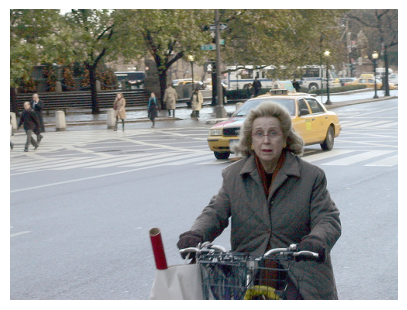

Beam search: a man in a black shirt is walking down a street
Greedy:      a man in a black and a black shirt is riding a street
References:
    an elderly woman is riding a bicycle in the city as a yellow taxi is about to pass by .
    An elderly woman rides a bicycle along a city street .
    An older woman with blond hair rides a bicycle down the street .
    A woman in a grey overcoat rides her bicycle along a street .
    Older woman wearing glassses riding a bicycle with a shopping bag on the handle , yellow car is in the background .


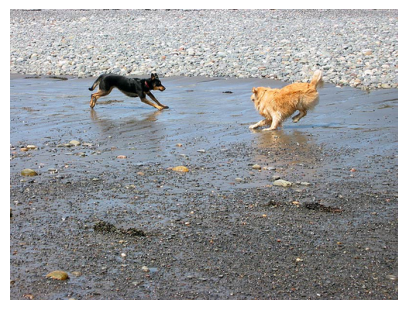

Beam search: a small dog in a red jacket and a white dog in the sand
Greedy:      a small dog in a red jacket and white dog on a rocky path
References:
    A black dog and a golden dog approaching one another
    A black dog and tan dog run towards each other on a beach .
    a black dog is approaching a golden dog on pebbly beach .
    Two dogs playing on a rocky beach .
    Two dogs running on the sand .


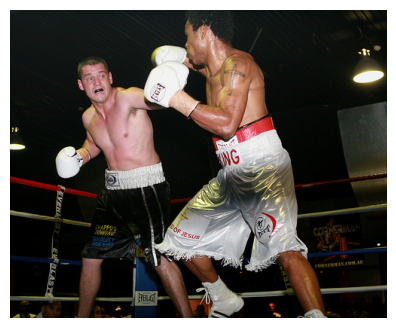

Beam search: a young boy wearing a red and white shirt is jumping in the air
Greedy:      a young boy in a red shirt is jumping on a red and white floor
References:
    A boxer in black trunks taking a swing at a boxer in white trunks .
    a man in black shorts is boxing against and man in white shorts .
    A man wearing black boxing shorts and white boxing gloves and a man in white boxing shorts and white boxing gloves are fighting in the ring .
    Two boxers fight in a well-lit ring surrounded by poorly-lit seating .
    Two men battle it out in a boxing match with white gloves .


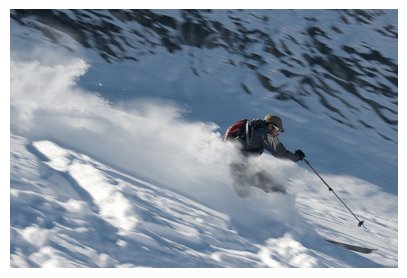

Beam search: a snowboarder in the snow
Greedy:      a skier is skiing down a hill
References:
    A man is skiing down a mountain .
    A person dressed in red and grey is skiing down a snowy slope .
    a skier is throwing up snow as he skis off piste .
    A skier skiing downhill in a cloud of snow .
    A skier wearing white sunglasses is skiing down a snowy mountain very fast .


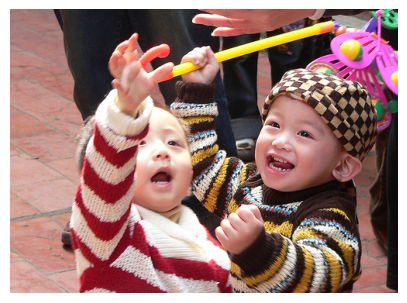

Beam search: a little girl in a red shirt is holding a baby
Greedy:      a little girl in a red shirt and blue shirt is holding a baby
References:
    One child reaches up for something while another stands beside him .
    One child with a colourful toy and another child reaching up .
    Two babies in sweaters playing with a toy .
    Two children have expressions of happiness as they reach for something out of sight .
    Two kids playing on a street


In [15]:
sample_names = np.random.default_rng(SEED).choice(test_names, size=5, replace=False)
sample_features = test_features[[test_names.index(name) for name in sample_names]]
beam_captions = generate_captions(best_model, sample_features, beam_width=BEAM_WIDTH)
greedy_captions = generate_captions(best_model, sample_features)

for name, beam_caption, greedy_caption in zip(sample_names, beam_captions, greedy_captions):
    plt.figure(figsize=(5, 4))
    plt.imshow(plt.imread(IMAGES_PATH / name))
    plt.axis("off")
    plt.show()
    print("Beam search:", beam_caption)
    print("Greedy:     ", greedy_caption)
    print("References:")
    for caption in test_data[name]:
        print("   ", caption)